In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import episcanpy as epi
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import h5py
import glob
import os

from pathlib import Path
from scipy import io
from helps import *

# Raw CM

In [2]:
adata=sc.read_h5ad("Datasets/Spleen/RawFiles/spleen_lymph_206.h5ad")
adata.X=scipy.sparse.csr_matrix(adata.X, dtype="int32")
adata.layers["raw"]=adata.X.copy()
adata

AnnData object with n_obs × n_vars = 15820 × 13553
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'cell_types'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode'
    uns: 'protein_names', 'version'
    obsm: 'protein_expression'
    layers: 'raw'

In [3]:
adata=adata[adata.obs.seurat_hash_id=="Spleen"]
adata.obs.rename({"cell_types":"CellType"}, axis=1, inplace=True)
adata

View of AnnData object with n_obs × n_vars = 8401 × 13553
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode'
    uns: 'protein_names', 'version'
    obsm: 'protein_expression'
    layers: 'raw'

In [4]:
adata=adata[adata.obs.batch_indices==1]
sc.pp.scrublet(adata)
adata

AnnData object with n_obs × n_vars = 4029 × 13553
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'cell_types', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode'
    uns: 'protein_names', 'version', 'scrublet'
    obsm: 'protein_expression'
    layers: 'raw'

In [ ]:
adata.obs.rename({"cell_types":"CellType"}, axis=1, inplace=True)
adata.write("Datasets/Spleen/CM/Spleen_GEX_Raw.h5ad", compression="gzip")

In [6]:
adt_var=pd.DataFrame(adata.uns["protein_names"], index=adata.uns["protein_names"], columns=["Protein"])
adt=sc.AnnData(X=scipy.sparse.csr_matrix(adata.obsm["protein_expression"], dtype="int32"), obs=adata.obs, var=adt_var)
adt

AnnData object with n_obs × n_vars = 4029 × 209
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'Protein'

In [7]:
adt.write("Datasets/Spleen/CM/Spleen_Spleen_Raw.h5ad", compression="gzip")

## mRNA & lncRNA

In [9]:
adata=sc.read_h5ad("Datasets/Spleen/CM/Spleen_GEX_Raw.h5ad")
adata.var.head()

,gene_ids,feature_types,highly_variable,highly_variable_mean_variance,encode,hvg_encode
index,,,,,,
Mrpl15,ENSMUSG00000033845,Gene Expression,False,0.945170,None,False
Lypla1,ENSMUSG00000025903,Gene Expression,False,0.934502,None,False
Tcea1,ENSMUSG00000033813,Gene Expression,False,0.843164,None,False
Atp6v1h,ENSMUSG00000033793,Gene Expression,False,0.908304,None,False
Rb1cc1,ENSMUSG00000025907,Gene Expression,False,0.910511,None,False


In [10]:
names = ["chr", "source", "type", "start", "stop", "score", "strand", "frame", "attribute"]
gtf_file="../AnnotRef/mm/gencode.vM33.annotation.gtf.gz"
gtf=pd.read_csv(gtf_file, sep="\t", header=None, comment="#", names=names, dtype={"chr": str})
gtf=gtf[(gtf["type"]=="gene") & (gtf["source"]=="HAVANA")]
gene_names=[attr.replace("gene_id", "gene_name").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_name")]
gene_names=[g.split(" ")[1][1:] for g in gene_names]
tmp = [attr.replace("gene_type", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_type ")]
if not tmp:
    tmp = [attr.replace("gene_biotype", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_biotype ")]

info=pd.DataFrame(data=[gene_names,tmp], index=["GeneName","GeneType"]).T
info.head()

,GeneName,GeneType
0,4933401J01Rik,TEC
1,Xkr4,protein_coding
2,Gm18956,processed_pseudogene
3,Gm37180,TEC
4,Gm37363,TEC


In [11]:
mRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="protein_coding"]["GeneName"]])]
print(mRNA.shape)
mRNA.write("Datasets/Spleen/CM/Spleen_mRNA_Raw.h5ad", compression="gzip")

(4029, 11554)


In [12]:
lncRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="lncRNA"]["GeneName"]])]
print(lncRNA.shape)
lncRNA.write("Datasets/Spleen/CM/Spleen_lncRNA_Raw.h5ad", compression="gzip")

(4029, 894)


# Processing

## GEX

In [4]:
adata=sc.read_h5ad("Datasets/Spleen/CM/Spleen_GEX_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 4029 × 13553
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode'
    uns: 'protein_names', 'scrublet', 'version'
    obsm: 'protein_expression'
    layers: 'raw'

In [9]:
epi.pp.qc_stats(adata, verbose=False)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1).A1/adata.obs['n_counts']

In [10]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.025)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.025)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

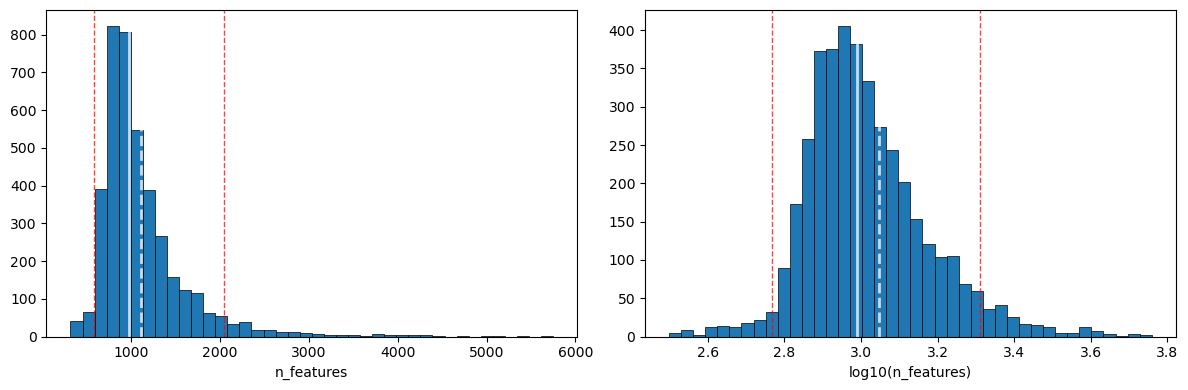

Max:	5749
Median:	976.0
Mean:	1113.7321916108215
Min:	315


In [11]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

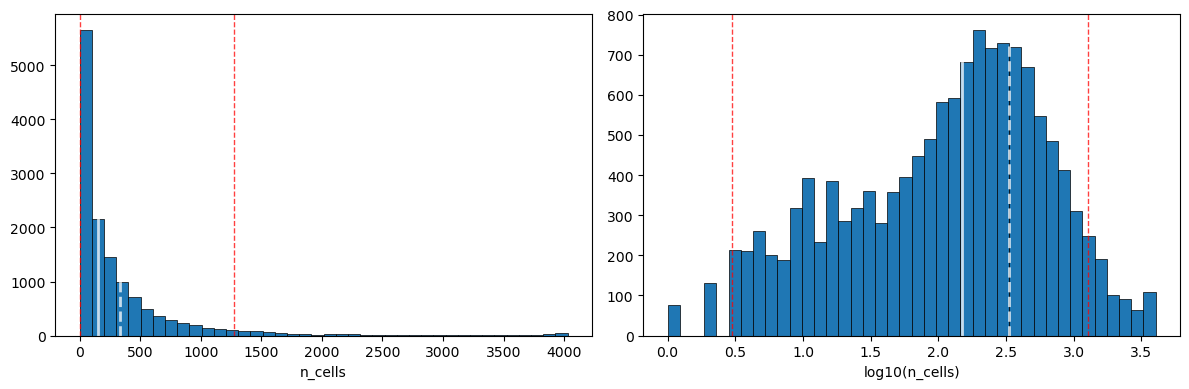

Max:	4028
Median:	149.0
Mean:	331.08736073194126
Min:	0


In [12]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

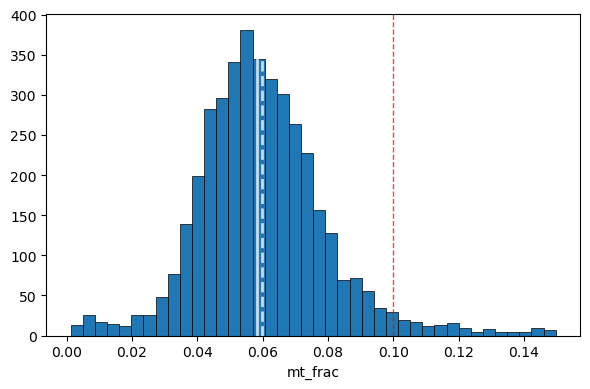

Max:	0.14977168949771688
Median:	0.05825242718446602
Mean:	0.05980683387163668
Min:	0.0012062726176115801


In [13]:
epi.pl.histogram(adata, "mt_frac", max_threshold=0.1, show_log=False)

In [14]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.1]
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 3596 × 12668
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'protein_names', 'scrublet', 'version'
    obsm: 'protein_expression'

In [15]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')

In [16]:
min_var = np.quantile(adata.var.variances_norm, 0.6)
adata=adata[:, adata.var.variances_norm>min_var]
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 3596 × 5067
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'protein_names', 'scrublet', 'version', 'hvg', 'log1p'
    obsm: 'protein_expression'

In [17]:
adata.write("Datasets/Spleen/CM/Spleen_GEX_Def.h5ad", compression="gzip")

## ADT

In [18]:
adata=sc.read_h5ad("Datasets/Spleen/CM/Spleen_ADT_Raw.h5ad")
adata.var["highly_variable"]=True
adata

AnnData object with n_obs × n_vars = 4029 × 209
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'Protein', 'highly_variable'

In [19]:
sc.pp.normalize_total(adata)

In [20]:
sc.pp.log1p(adata)

In [21]:
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 4029 × 209
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'Protein', 'highly_variable'
    uns: 'log1p'

In [22]:
adata.write("Datasets/Spleen/CM/Spleen_ADT_Def.h5ad", compression="gzip")

## mRNA

In [5]:
adata=sc.read_h5ad("Datasets/Spleen/CM/Spleen_mRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 4029 × 11554
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode'
    uns: 'protein_names', 'scrublet', 'version'
    obsm: 'protein_expression'
    layers: 'raw'

In [58]:
sc.pp.scrublet(adata)

In [59]:
epi.pp.qc_stats(adata, verbose=True)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1).A1/adata.obs['n_counts']

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [60]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.1)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

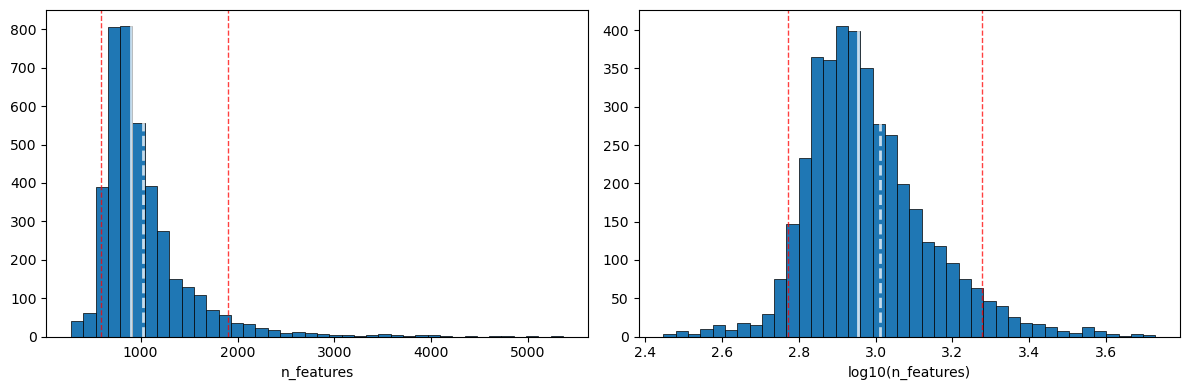

Max:	5360
Median:	900.0
Mean:	1029.017622238769
Min:	280


In [61]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

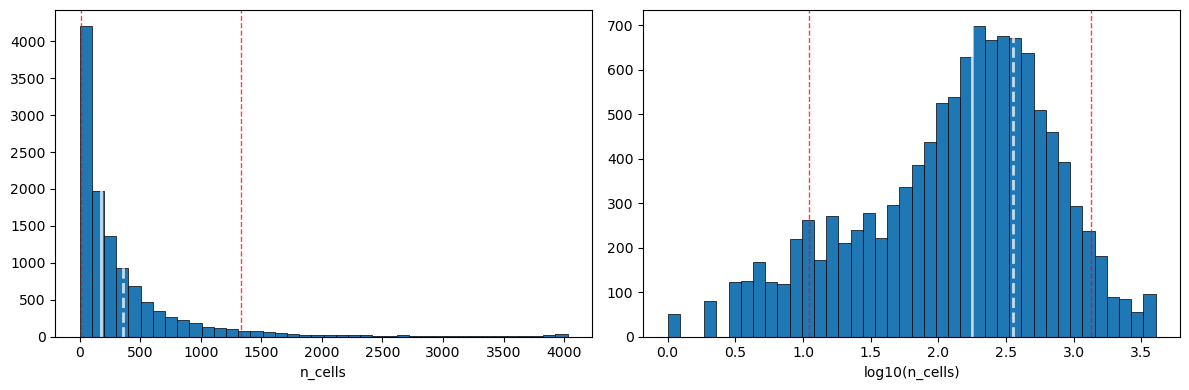

Max:	4028
Median:	178.0
Mean:	358.8291500778951
Min:	0


In [62]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

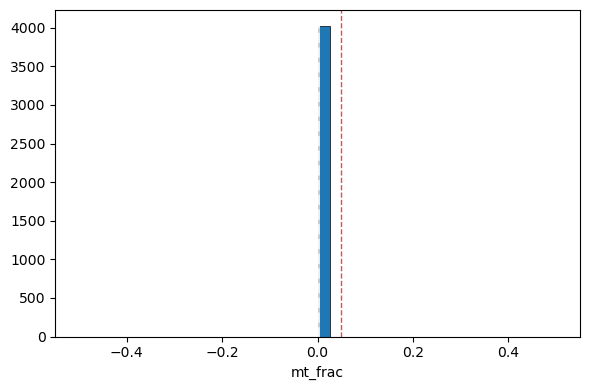

Max:	0.0
Median:	0.0
Mean:	0.0
Min:	0.0


In [63]:
epi.pl.histogram(adata, "mt_frac", max_threshold=0.05, show_log=False)

In [64]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.05]
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 3576 × 9884
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'protein_names', 'scrublet', 'version'
    obsm: 'protein_expression'

In [65]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.6)
adata=adata[:, adata.var.variances_norm>min_var]

In [66]:
epi.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 3576 × 3954
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'protein_names', 'scrublet', 'version', 'hvg', 'log1p'
    obsm: 'protein_expression'

In [67]:
adata.write("Datasets/Spleen/CM/Spleen_mRNA_Def.h5ad", compression="gzip")

## lncRNA

In [6]:
adata=sc.read_h5ad("Datasets/Spleen/CM/Spleen_lncRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 4029 × 894
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode'
    uns: 'protein_names', 'scrublet', 'version'
    obsm: 'protein_expression'
    layers: 'raw'

In [69]:
epi.pp.qc_stats(adata, verbose=True)

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [70]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.02)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

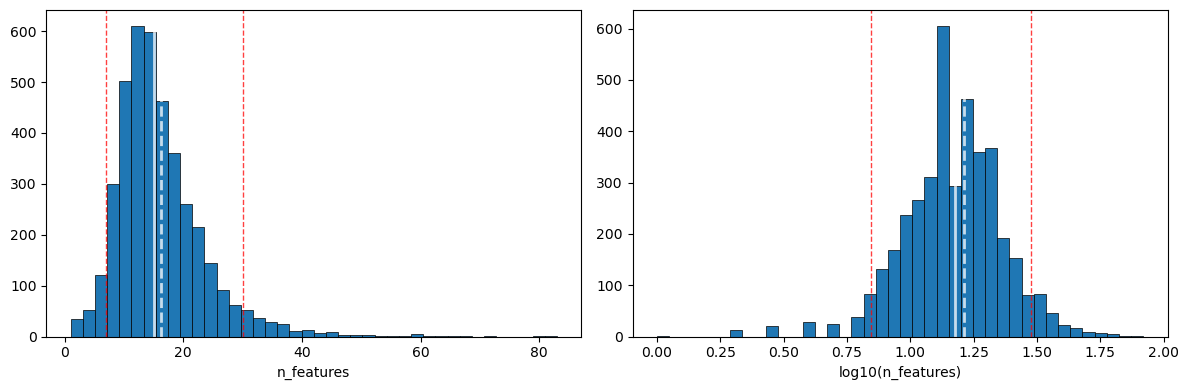

Max:	83
Median:	15.0
Mean:	16.26607098535617
Min:	1


In [71]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

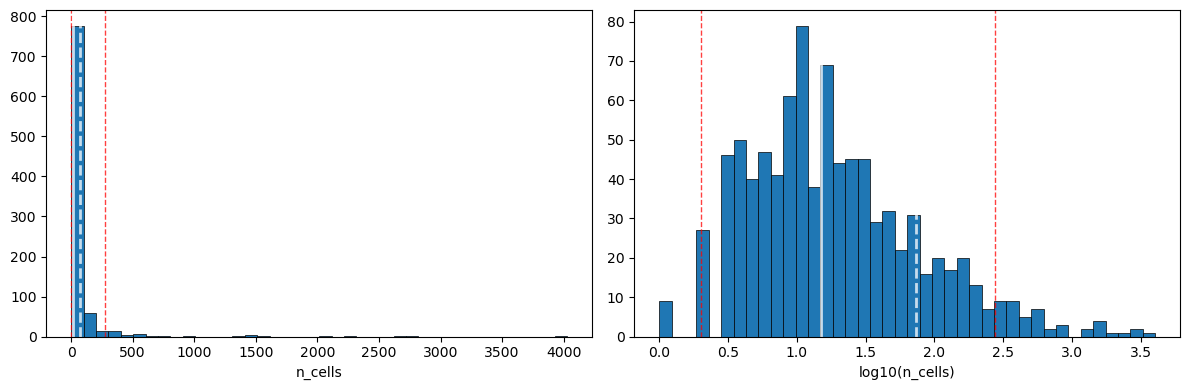

Max:	4028
Median:	15.0
Mean:	73.30648769574944
Min:	0


In [72]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

In [73]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata

AnnData object with n_obs × n_vars = 3692 × 840
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'protein_names', 'scrublet', 'version'
    obsm: 'protein_expression'

In [74]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.05)
adata=adata[:, adata.var.variances_norm>min_var]

In [75]:
epi.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 3643 × 798
    obs: 'n_protein_counts', 'n_proteins', 'seurat_hash_id', 'batch_indices', 'hash_id', 'n_genes', 'percent_mito', 'leiden_subclusters', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_mean_variance', 'encode', 'hvg_encode', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'protein_names', 'scrublet', 'version', 'hvg', 'log1p'
    obsm: 'protein_expression'

In [76]:
adata.write("Datasets/Spleen/CM/Spleen_lncRNA_Def.h5ad", compression="gzip")

## Muon objects

In [6]:
import muon as mu
adt=sc.read_h5ad(f"Datasets/Spleen/CM/Spleen_ADT_Def.h5ad")
gex=sc.read_h5ad(f"Datasets/Spleen/CM/Spleen_GEX_Def.h5ad")
mrna=sc.read_h5ad(f"Datasets/Spleen/CM/Spleen_mRNA_Def.h5ad")
lncrna=sc.read_h5ad(f"Datasets/Spleen/CM/Spleen_lncRNA_Def.h5ad")

#ADT + GEX
print("ADT + GEX")
inter=intersection([adt.obs.index, gex.obs.index])
mudata=mu.MuData({"ADT" : adt[inter], "GEX" : gex[inter]})
mudata.write_h5mu(f"Datasets/Spleen/CM/Spleen_ADT_GEX_Def.h5mu", compression="gzip")

#ADT + mRNA
print("ADT + mRNA")
inter=intersection([adt.obs.index, mrna.obs.index])
mudata=mu.MuData({"ADT" : adt[inter], "mRNA" : mrna[inter]})
mudata.write_h5mu(f"Datasets/Spleen/CM/Spleen_ADT_mRNA_Def.h5mu", compression="gzip")

#ADT + lncRNA
print("ADT + lncRNA")
inter=intersection([adt.obs.index, lncrna.obs.index])
mudata=mu.MuData({"ADT" : adt[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/Spleen/CM/Spleen_ADT_lncRNA_Def.h5mu", compression="gzip")

#mRNA + lncRNA
print("mRNA + lncRNA")
inter=intersection([mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/Spleen/CM/Spleen_mRNA_lncRNA_Def.h5mu", compression="gzip")

#ADT + mRNA + lncRNA
print("ADT + mRNA + lncRNA")
inter=intersection([adt.obs.index, mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"ADT" : adt[inter], "mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/Spleen/CM/Spleen_ADT_mRNA_lncRNA_Def.h5mu", compression="gzip")

ADT + GEX
ADT + mRNA
ADT + lncRNA
mRNA + lncRNA
ADT + mRNA + lncRNA


# CTA

In [2]:
df=sc.read_h5ad("Datasets/Spleen/CM/Spleen_GEX_Raw.h5ad").obs
df.head()

,n_protein_counts,n_proteins,seurat_hash_id,batch_indices,hash_id,n_genes,percent_mito,leiden_subclusters,CellType,doublet_score,predicted_doublet
index,,,,,,,,,,,
AAACCCAAGGTATCTC-2,2871.0,192,Spleen,1,Spleen,1276,0.036945,0,CD4 T,0.031286,False
AAACCCATCCTAGAGT-2,3534.0,187,Spleen,1,Spleen,1010,0.051102,"10,1",ICOS-high Tregs,0.061728,False
AAACCCATCTCATTGT-2,2240.0,188,Spleen,1,Spleen,948,0.059006,5,Mature B,0.071359,False
AAACGAACAAAGGGCT-2,2605.0,196,Spleen,1,Spleen,973,0.061047,2,CD8 T,0.031286,False
AAACGAACAAGTCCAT-2,3058.0,196,Spleen,1,Spleen,1513,0.064380,13,B1 B,0.083333,False


In [3]:
df[["CellType"]].to_csv("Datasets/Spleen/Spleen_Metadata.tsv.gz", sep="\t", compression="gzip")